## Exploratory Data Analysis with DuckDB SQL

In [41]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns",None)

con = duckdb.connect()

In [42]:
SALES_PATH = "../data/processed/*.parquet"

In [43]:
# testing connection and reading data
df = con.execute(f"""select * from read_parquet('{SALES_PATH}') limit 5""").df()
df

,id,item_id,dept_id,cat_id,store_id,state_id,date,wm_yr_wk,sales,sell_price,weekday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,2011-01-29,11101,0,NaN,Saturday,1,2011,None,None,None,None,0
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,2011-01-29,11101,0,NaN,Saturday,1,2011,None,None,None,None,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,2011-01-29,11101,0,NaN,Saturday,1,2011,None,None,None,None,0
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,2011-01-29,11101,0,NaN,Saturday,1,2011,None,None,None,None,0
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,2011-01-29,11101,0,NaN,Saturday,1,2011,None,None,None,None,0


In [46]:
query = f"""

        select count(*) as rows,
                sum(sales) as total_sales,
                mean(sales) as avg_sales,
                median(sales) as median_sales,
                min(sales) as min_sales,
                max(sales) as max_sales
        from read_parquet('{SALES_PATH}')
    """

result = con.execute(query).df()
result

,rows,total_sales,avg_sales,median_sales,min_sales,max_sales
0,58327370,65695409.0,1.126322,0.0,0,763


In [112]:
query = f"""

        select count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
    """

result = con.execute(query).df()
result

,total_observations,zero_sales,zero_sales_pct
0,58327370,39777094,68.2


In [116]:
query = f"""

        select store_id, item_id,
            count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
        group by store_id,item_id
        order by store_id,item_id
    """

result = con.execute(query).df()
result

,store_id,item_id,total_observations,zero_sales,zero_sales_pct
0,CA_1,FOODS_1_001,1913,1078,56.35
1,CA_1,FOODS_1_002,1913,1278,66.81
2,CA_1,FOODS_1_003,1913,1011,52.85
3,CA_1,FOODS_1_004,1913,616,32.20
4,CA_1,FOODS_1_005,1913,1030,53.84
...,...,...,...,...,...
30485,WI_3,HOUSEHOLD_2_512,1913,1468,76.74
30486,WI_3,HOUSEHOLD_2_513,1913,1512,79.04
30487,WI_3,HOUSEHOLD_2_514,1913,1733,90.59
30488,WI_3,HOUSEHOLD_2_515,1913,1811,94.67


In [117]:
query = f"""

        select date,
            count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
        group by date
        order by date
    """

result = con.execute(query).df()
result

,date,total_observations,zero_sales,zero_sales_pct
0,2011-01-29,30490,23511,77.11
1,2011-01-30,30490,23610,77.44
2,2011-01-31,30490,24500,80.35
3,2011-02-01,30490,24518,80.41
4,2011-02-02,30490,25422,83.38
...,...,...,...,...
1908,2016-04-20,30490,18015,59.08
1909,2016-04-21,30490,18224,59.77
1910,2016-04-22,30490,17107,56.11
1911,2016-04-23,30490,15718,51.55


In [124]:
query = f"""

        select cat_id,
            count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
        group by cat_id
        order by cat_id
    """

result = con.execute(query).df()
result

,cat_id,total_observations,zero_sales,zero_sales_pct
0,FOODS,27489810,17049511,62.02
1,HOBBIES,10808450,8352777,77.28
2,HOUSEHOLD,20029110,14374806,71.77


In [ ]:
query = f"""

        select year,cat_id,
            count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
        group by cat_id
        order by cat_id
    """

result = con.execute(query).df()
result

In [125]:
query = f"""

        select date,cat_id,
            count(*) as total_observations,
            count(*) filter(where sales=0) as zero_sales,
            round(count(*) filter(where sales=0)/count(*)*100,2) as zero_sales_pct
        from read_parquet('{SALES_PATH}')
        group by date,cat_id
        order by date,cat_id
    """

result = con.execute(query).df()
result

,date,cat_id,total_observations,zero_sales,zero_sales_pct
0,2011-01-29,FOODS,14370,10448,72.71
1,2011-01-29,HOBBIES,5650,4632,81.98
2,2011-01-29,HOUSEHOLD,10470,8431,80.53
3,2011-01-30,FOODS,14370,10509,73.13
4,2011-01-30,HOBBIES,5650,4663,82.53
...,...,...,...,...,...
5734,2016-04-23,HOBBIES,5650,3668,64.92
5735,2016-04-23,HOUSEHOLD,10470,5724,54.67
5736,2016-04-24,FOODS,14370,6189,43.07
5737,2016-04-24,HOBBIES,5650,3674,65.03


In [48]:
query = f"""
        select store_id,
            sum(sales) as total_sales,
            avg(sales) as avg_sales
        from read_parquet('{SALES_PATH}')
        group by store_id
"""

result = con.execute(query).df()
result

,store_id,total_sales,avg_sales
0,WI_1,5149062.0,0.882787
1,CA_1,7698216.0,1.319829
2,CA_2,5685475.0,0.974753
3,TX_3,6089330.0,1.043992
4,WI_3,6427782.0,1.102018
5,CA_4,4103676.0,0.703559
6,WI_2,6544012.0,1.121945
7,CA_3,11188180.0,1.918170
8,TX_1,5595292.0,0.959291
9,TX_2,7214384.0,1.236878


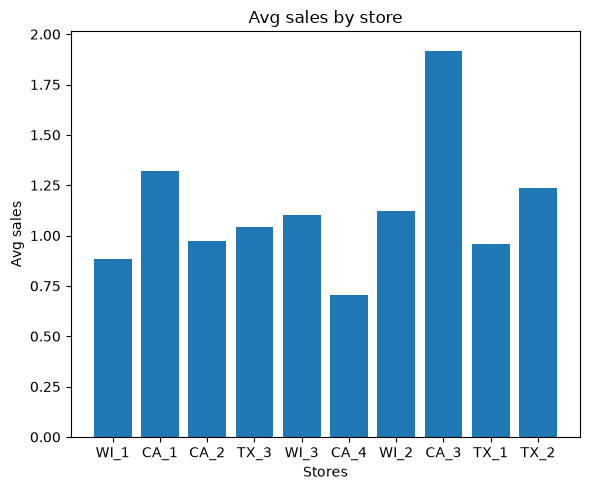

In [51]:
plt.figure(figsize=(6,5))
plt.bar(result["store_id"],result["avg_sales"])

plt.title("Avg sales by store")
plt.xlabel("Stores")
plt.ylabel("Avg sales")

plt.tight_layout()
plt.show()

In [52]:
query = f"""
        select state_id,
            sum(sales) as total_sales,
            avg(sales) as avg_sales
        from read_parquet('{SALES_PATH}')
        group by state_id
"""

result = con.execute(query).df()
result

,state_id,total_sales,avg_sales
0,CA,28675547.0,1.229078
1,TX,18899006.0,1.080054
2,WI,18120856.0,1.035583


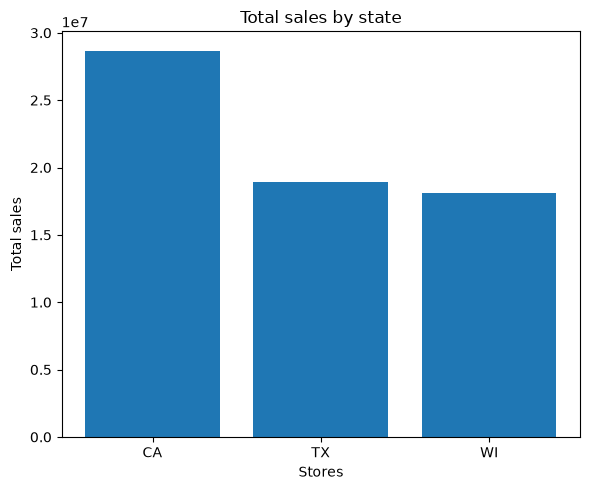

In [53]:
plt.figure(figsize=(6,5))
plt.bar(result["state_id"],result["total_sales"])

plt.title("Total sales by state")
plt.xlabel("Stores")
plt.ylabel("Total sales")

plt.tight_layout()
plt.show()

In [54]:
query = f"""
        select cat_id,
            sum(sales) as total_sales,
            avg(sales) as avg_sales
        from read_parquet('{SALES_PATH}')
        group by cat_id
"""

result = con.execute(query).df()
result

,cat_id,total_sales,avg_sales
0,HOUSEHOLD,14480670.0,0.722981
1,HOBBIES,6124800.0,0.566668
2,FOODS,45089939.0,1.640242


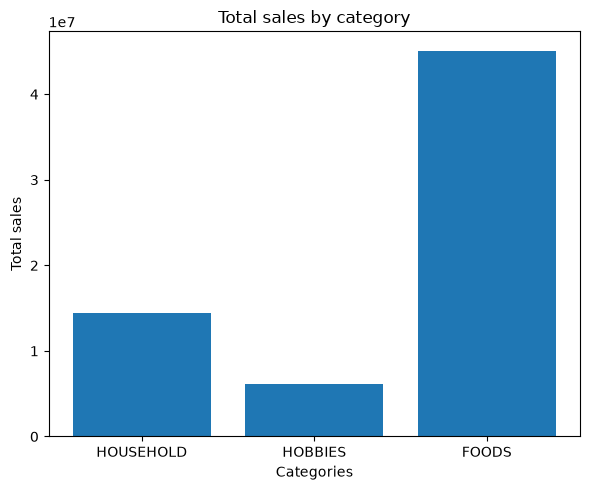

In [55]:
plt.figure(figsize=(6,5))
plt.bar(result["cat_id"],result["total_sales"])

plt.title("Total sales by category")
plt.xlabel("Categories")
plt.ylabel("Total sales")

plt.tight_layout()
plt.show()

In [56]:
query = f"""
        select dept_id,
            sum(sales) as total_sales,
            avg(sales) as avg_sales
        from read_parquet('{SALES_PATH}')
        group by dept_id
"""

result = con.execute(query).df()
result

,dept_id,total_sales,avg_sales
0,FOODS_1,5088041.0,1.231351
1,FOODS_2,7629822.0,1.002112
2,HOUSEHOLD_2,2980144.0,0.302493
3,HOUSEHOLD_1,11500526.0,1.130033
4,HOBBIES_1,5596460.0,0.703242
5,HOBBIES_2,528340.0,0.185358
6,FOODS_3,32372076.0,2.056155


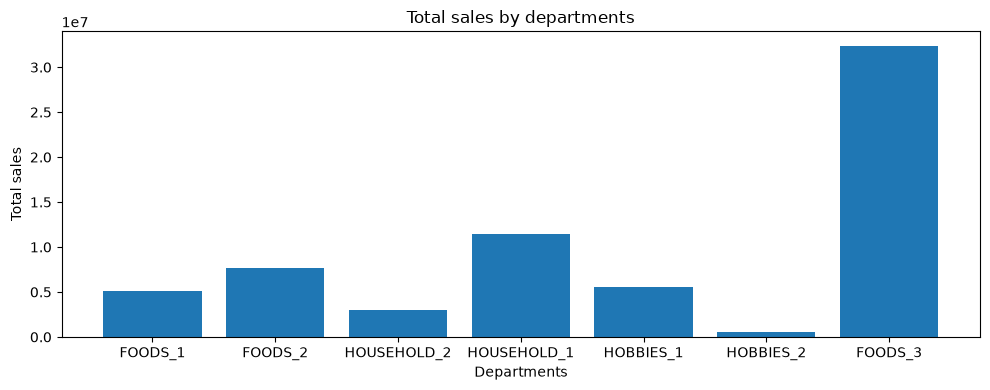

In [59]:
plt.figure(figsize=(10,4))
plt.bar(result["dept_id"],result["total_sales"])

plt.title("Total sales by departments")
plt.xlabel("Departments")
plt.ylabel("Total sales")

plt.tight_layout()
plt.show()

In [70]:
# Yearly sales

query = f"""
        select year,
            sum(sales) as total_sales,
        from read_parquet('{SALES_PATH}')
        group by year
        order by year
"""

result = con.execute(query).df() 
result

,year,total_sales
0,2011,8856585.0
1,2012,12061837.0
2,2013,13135753.0
3,2014,13089776.0
4,2015,13800811.0
5,2016,4750647.0


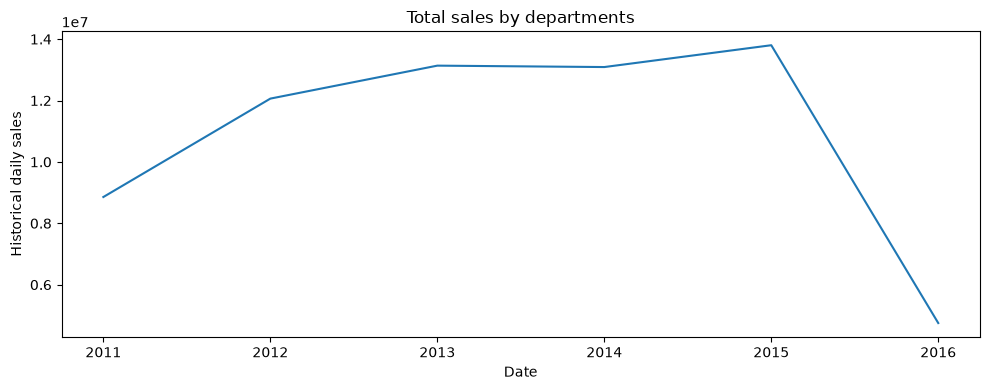

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(result["year"],result["total_sales"])

plt.title("Total sales by year")
plt.xlabel("Date")
plt.ylabel("Yearly sales")

plt.tight_layout()
plt.show()

In [92]:
# Monthly sales

query = f"""
        select month,
            sum(sales) as total_sales,
        from read_parquet('{SALES_PATH}')
        group by month
        order by month
"""

result = con.execute(query).df() 
result

,month,total_sales
0,1,5345511.0
1,2,5889589.0
2,3,6387210.0
3,4,5961011.0
4,5,5038097.0
5,6,5250212.0
6,7,5443975.0
7,8,5571730.0
8,9,5321889.0
9,10,5380589.0


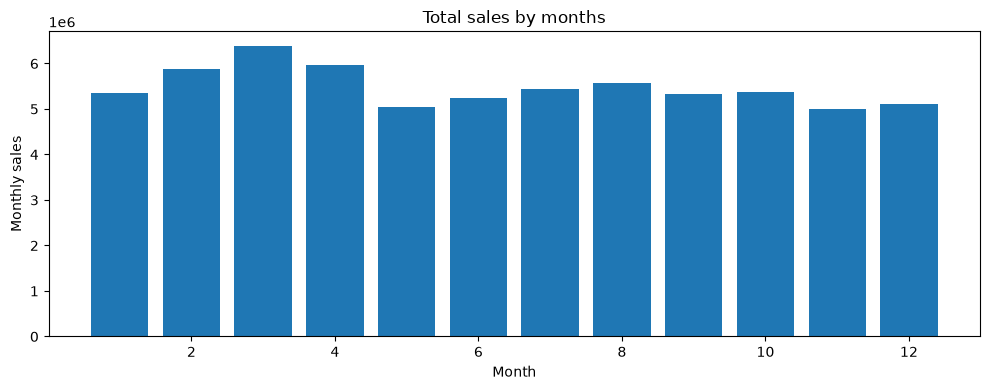

In [93]:
plt.figure(figsize=(10,4))
plt.bar(result["month"],result["total_sales"])

plt.title("Total sales by months")
plt.xlabel("Month")
plt.ylabel("Monthly sales")

plt.tight_layout()
plt.show()

In [78]:
# Weekly sales

query = f"""
        select weekday as week,
            sum(sales) as total_sales,
        from read_parquet('{SALES_PATH}')
        group by week
        order by week
"""

result = con.execute(query).df() 
result

,week,total_sales
0,Friday,9343694.0
1,Monday,8968860.0
2,Saturday,11383849.0
3,Sunday,11269626.0
4,Thursday,8245967.0
5,Tuesday,8290677.0
6,Wednesday,8192736.0


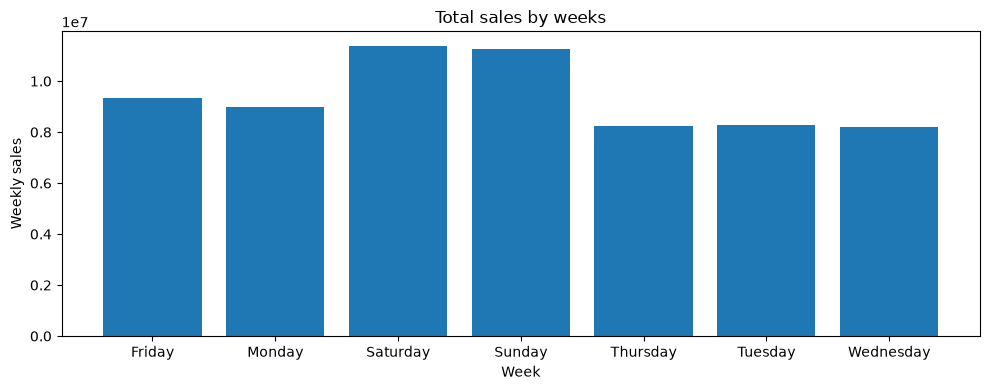

In [80]:
plt.figure(figsize=(10,4))
plt.bar(result["week"],result["total_sales"])

plt.title("Total sales by weeks")
plt.xlabel("Week")
plt.ylabel("Weekly sales")

plt.tight_layout()
plt.show()

In [84]:
# Daily sales

query = f"""
        select date,
            sum(sales) as total_sales,
        from read_parquet('{SALES_PATH}')
        group by date
        order by date
"""

result = con.execute(query).df() 
result

,date,total_sales
0,2011-01-29,32631.0
1,2011-01-30,31749.0
2,2011-01-31,23783.0
3,2011-02-01,25412.0
4,2011-02-02,19146.0
...,...,...
1908,2016-04-20,35343.0
1909,2016-04-21,35033.0
1910,2016-04-22,40517.0
1911,2016-04-23,48962.0


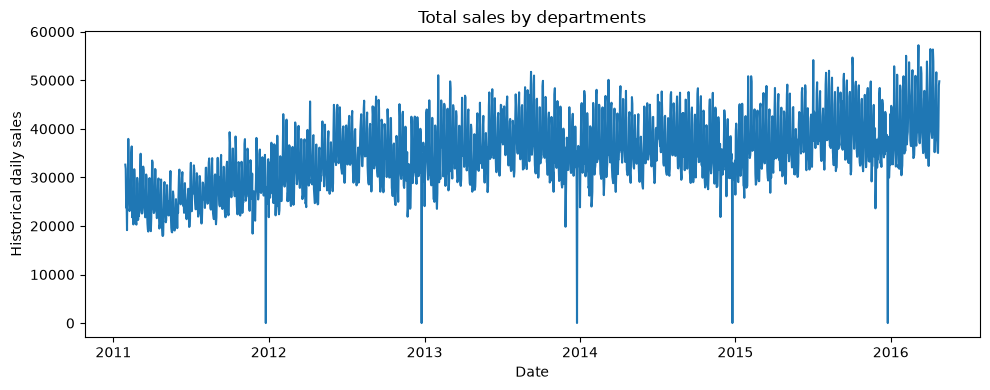

In [85]:
plt.figure(figsize=(10,4))
plt.plot(result["date"],result["total_sales"])

plt.title("Total sales by departments")
plt.xlabel("Date")
plt.ylabel("Historical daily sales")

plt.tight_layout()
plt.show()

In [111]:
# Daily sales

query = f"""
        select event_type_1,
            count(*) as total_event_count,
            sum(sales) as total_sales,
            avg(sales) as avg_sales
        from read_parquet('{SALES_PATH}')
        group by event_type_1
        
"""

result = con.execute(query).df() 
result["event_type_1"] = result["event_type_1"].fillna("No event")
result

,event_type_1,total_event_count,total_sales,avg_sales
0,Sporting,487840,572737.0,1.174026
1,Religious,1585480,1755556.0,1.107271
2,Cultural,1067150,1198216.0,1.122819
3,No event,53631910,60666516.0,1.131165
4,National,1554990,1502384.0,0.966170


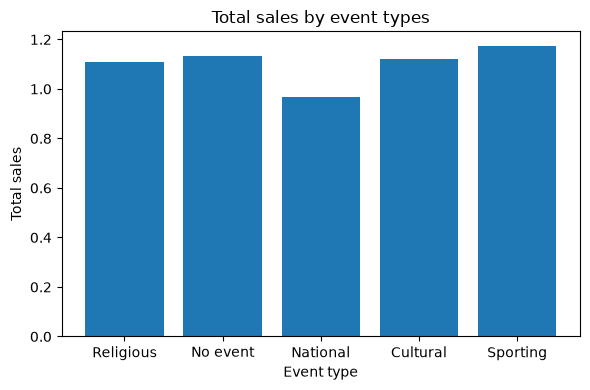

In [110]:
plt.figure(figsize=(6,4))
plt.bar(result["event_type_1"],result["avg_sales"])

plt.title("Total sales by event types")
plt.xlabel("Event type")
plt.ylabel("Total sales")

plt.tight_layout()
plt.show()